**PROCESAMIENTO PUNTUAL DE IMÁGENES**

**Participantes (alumnos):** Mateo Hernandez, Felipe Lucero

Una operación sobre una imagen de entrada se llama puntual cuando su resultado depende únicamente del valor del píxel de entrada en una posición dada.

**OPERADOR INVERSO O NEGATIVO**

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Función para mostrar la imagen original y su negativo
def display_images(original, negative, title_original, title_negative, cmap=None):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(original, cmap=cmap)
    plt.title(title_original)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(negative, cmap=cmap)
    plt.title(title_negative)
    plt.axis('off')

    plt.show()

### Imagen única de trabajo: `entrada/pelota.jpg`

Todo el cuaderno usa **la misma foto** (pelota sobre césped). En este repo va en **`entrada/pelota.jpg`** (estructura alineada al TP2). En Colab podés subir la carpeta `entrada` o el archivo y, si hace falta, ajustar la ruta. La siguiente celda la carga en **color** y en **grises** (`grayscale_image`) para umbrales y operadores.

In [11]:
import cv2
import numpy as np
from pathlib import Path


def _ruta_pelota(nombre: str = "pelota.jpg") -> str:
    """Busca la imagen en entrada/ (estructura del repo) o junto al notebook / cwd (Colab)."""
    bases: list[Path] = []
    vsc = globals().get("__vsc_ipynb_file__")
    if vsc:
        bases.append(Path(vsc).resolve().parent)
    bases.append(Path.cwd().resolve())
    for p in Path.cwd().parents:
        bases.append(p.resolve())
        if len(bases) > 24:
            break

    candidatos: list[Path] = []
    for base in bases:
        candidatos.append(base / "entrada" / nombre)
        candidatos.append(base / nombre)

    for c in candidatos:
        if c.is_file():
            return str(c)

    raise FileNotFoundError(
        f"No se encuentra {nombre}. Colocá el archivo en entrada/{nombre} (raíz del repo) "
        f"o en la carpeta del notebook. cwd={Path.cwd()}"
    )


RUTA_PELOTA = _ruta_pelota("pelota.jpg")
pelota_bgr = cv2.imread(RUTA_PELOTA)
if pelota_bgr is None:
    raise FileNotFoundError(f"OpenCV no pudo leer el archivo: {RUTA_PELOTA}")

color_image = pelota_bgr
pelota_rgb = cv2.cvtColor(pelota_bgr, cv2.COLOR_BGR2RGB)
color_image_rgb = pelota_rgb
grayscale_image = cv2.cvtColor(pelota_bgr, cv2.COLOR_BGR2GRAY)

print("OK:", RUTA_PELOTA, "BGR", pelota_bgr.shape, "| gris min/max:", int(grayscale_image.min()), int(grayscale_image.max()))


OK: C:\Users\mateo\OneDrive\Desktop\Trabajo Practico 3\pelota.jpg BGR (540, 960, 3) | gris min/max: 0 255


### 1. Imagen Binaria

Para una imagen binaria (blanco y negro puro), el negativo se obtiene invirtiendo los valores de los píxeles (0 se convierte en 255 y 255 en 0).

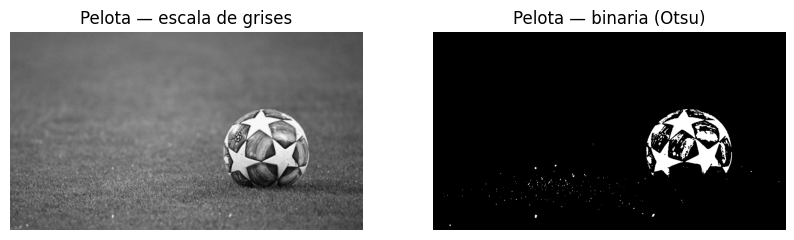

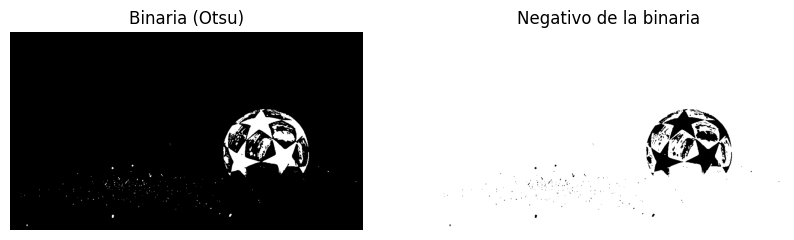

In [12]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

if "display_images" not in globals():
    def display_images(original, negative, title_original, title_negative, cmap=None):
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(original, cmap=cmap)
        plt.title(title_original)
        plt.axis("off")
        plt.subplot(1, 2, 2)
        plt.imshow(negative, cmap=cmap)
        plt.title(title_negative)
        plt.axis("off")
        plt.show()


# Binarización automática (Otsu) sobre la misma pelota en grises
if globals().get("grayscale_image") is None:
    raise RuntimeError("Ejecuta primero la celda que carga pelota.jpg (grayscale_image).")

_, binary_image = cv2.threshold(grayscale_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
binary_negative = 255 - binary_image

display_images(
    grayscale_image,
    binary_image,
    "Pelota — escala de grises",
    "Pelota — binaria (Otsu)",
    cmap="gray",
)
display_images(
    binary_image,
    binary_negative,
    "Binaria (Otsu)",
    "Negativo de la binaria",
    cmap="gray",
)


### 2. Imagen en Escala de Grises

Para una imagen en escala de grises, el negativo se calcula restando cada valor de píxel de 255 (asumiendo 8 bits por píxel, donde 255 es el blanco máximo).

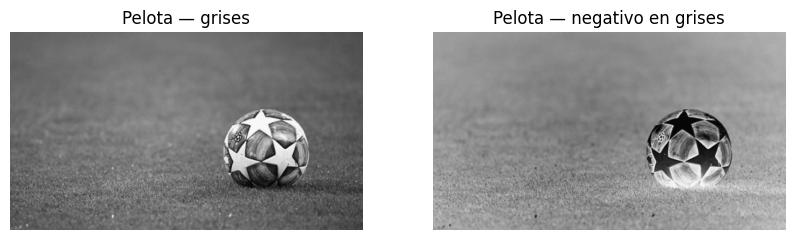

In [13]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

if "display_images" not in globals():
    def display_images(original, negative, title_original, title_negative, cmap=None):
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(original, cmap=cmap)
        plt.title(title_original)
        plt.axis("off")
        plt.subplot(1, 2, 2)
        plt.imshow(negative, cmap=cmap)
        plt.title(title_negative)
        plt.axis("off")
        plt.show()


if globals().get("grayscale_image") is None:
    raise RuntimeError("Ejecuta primero la celda que carga pelota.jpg.")

grayscale_negative = 255 - grayscale_image
display_images(
    grayscale_image,
    grayscale_negative,
    "Pelota — grises",
    "Pelota — negativo en grises",
    cmap="gray",
)


### 3. Imagen en Color

Para una imagen en color (RGB), el negativo se calcula aplicando la misma operación (`255 - valor_del_píxel`) a cada canal (Rojo, Verde, Azul) de cada píxel.

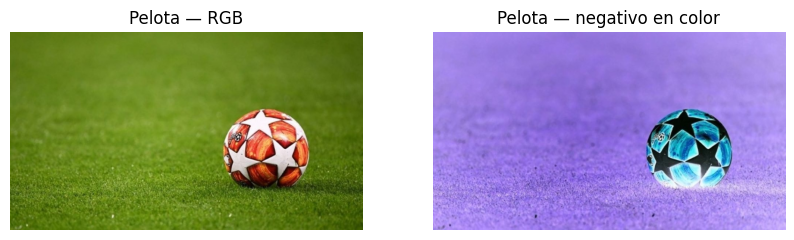

In [14]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

if "display_images" not in globals():
    def display_images(original, negative, title_original, title_negative, cmap=None):
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(original, cmap=cmap)
        plt.title(title_original)
        plt.axis("off")
        plt.subplot(1, 2, 2)
        plt.imshow(negative, cmap=cmap)
        plt.title(title_negative)
        plt.axis("off")
        plt.show()


if globals().get("color_image_rgb") is None:
    raise RuntimeError("Ejecuta primero la celda que carga pelota.jpg.")

color_negative = 255 - color_image_rgb
display_images(
    color_image_rgb,
    color_negative,
    "Pelota — RGB",
    "Pelota — negativo en color",
)


**OPERADOR UMBRAL**

Sea i una imagen digital en escala de grises, entonces

i1= VRRMin para todo p<=p1

i1= VRRMax para todo p>p1

### Implementación — Operador umbral (global, dos niveles)

Con un único umbral `p1`: los píxeles con intensidad `p ≤ p1` pasan a `VRRMin` y el resto a `VRRMax` (imagen binaria o dos niveles de gris).

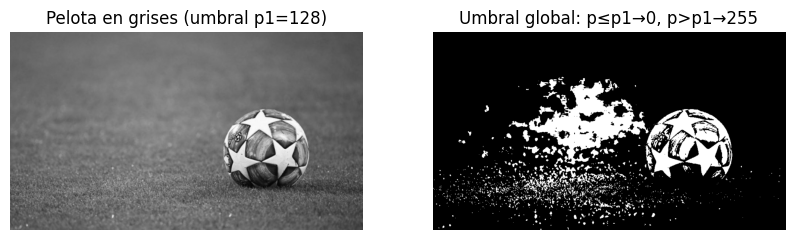

In [15]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

if "display_images" not in globals():
    def display_images(original, negative, title_original, title_negative, cmap=None):
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(original, cmap=cmap)
        plt.title(title_original)
        plt.axis("off")
        plt.subplot(1, 2, 2)
        plt.imshow(negative, cmap=cmap)
        plt.title(title_negative)
        plt.axis("off")
        plt.show()


if globals().get("grayscale_image") is None:
    raise RuntimeError("Ejecuta primero la celda que carga pelota.jpg.")

p1 = 128
VRRMin = 0
VRRMax = 255
simple_threshold_image = np.where(grayscale_image <= p1, VRRMin, VRRMax).astype(np.uint8)

display_images(
    grayscale_image,
    simple_threshold_image,
    f"Pelota en grises (umbral p1={p1})",
    f"Umbral global: p≤p1→{VRRMin}, p>p1→{VRRMax}",
    cmap="gray",
)


**OPERADOR UMBRAL POR INTERVALO PARA RESULTADOS BINARIOS**

Se utiliza para crear una imagen de salida como una imagen binaria a partir de una imagen en escala de grises, donde el nivel de transición está dado ahora por dos parámetros de entrada p1 y p2. Sea i una imagen digital en escala de grises, entonces

   i1= 0 para todo p<=p1 o p>=p2

   i1= VRRMax para todo p1<p<p2

### Implementación del Operador Umbral por Intervalo (Resultados Binarios)

Este operador toma una imagen en escala de grises y dos valores de umbral, `p1` y `p2`. Los píxeles cuyos valores están *entre* `p1` y `p2` se establecen al valor máximo (`255`), y el resto se establecen a `0`, creando una imagen binaria.

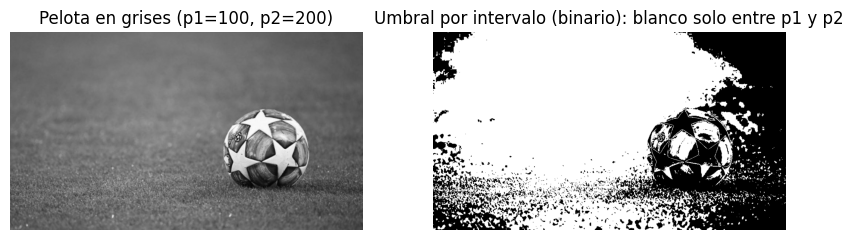

In [16]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

if "display_images" not in globals():
    def display_images(original, negative, title_original, title_negative, cmap=None):
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(original, cmap=cmap)
        plt.title(title_original)
        plt.axis("off")
        plt.subplot(1, 2, 2)
        plt.imshow(negative, cmap=cmap)
        plt.title(title_negative)
        plt.axis("off")
        plt.show()


if globals().get("grayscale_image") is None:
    raise RuntimeError("Ejecuta primero la celda que carga pelota.jpg.")

p1 = 100
p2 = 200
VRRMax = 255
interval_threshold_image = np.zeros_like(grayscale_image, dtype=np.uint8)
interval_threshold_image[(grayscale_image > p1) & (grayscale_image < p2)] = VRRMax

display_images(
    grayscale_image,
    interval_threshold_image,
    f"Pelota en grises (p1={p1}, p2={p2})",
    "Umbral por intervalo (binario): blanco solo entre p1 y p2",
    cmap="gray",
)


### Paso 1: Eliminar el Fondo Verde

Para eliminar el fondo verde, utilizaremos la detección de color. Convertiremos la imagen al espacio de color HSV (Hue, Saturation, Value), que es ideal para la segmentación de colores, y definiremos un rango para el color verde. Cualquier píxel dentro de este rango se considerará parte del fondo y se puede enmascarar o hacer transparente.

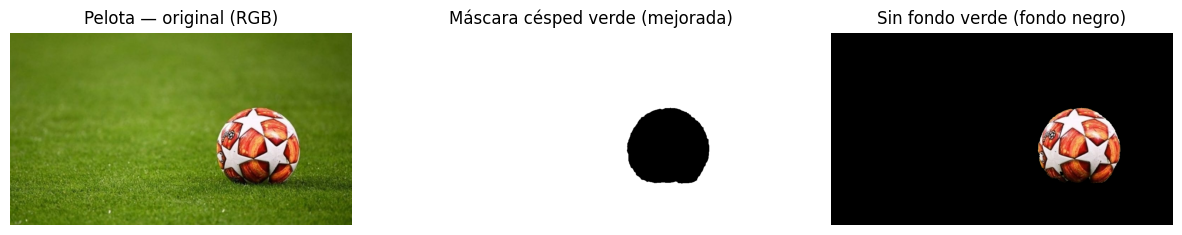

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Si ves este comentario, esta celda es la VERSION MEJORADA (no el umbral HSV simple).


def mascara_cesped_y_fg(pelota_bgr):
    """
    Césped: HSV acotado + canal G dominante; se excluyen blancos y rojos de la pelota.
    Morfología ligera (el cierre grande anterior tapaba la pelota y dejaba la máscara
    en casi toda la imagen). Luego mayor componente de primer plano y recorte verdoso.
    """
    hsv = cv2.cvtColor(pelota_bgr, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    hh = h.astype(np.int32)
    ss = s.astype(np.int32)
    vv = v.astype(np.int32)

    bgr = pelota_bgr.astype(np.int32)
    b, g, r = bgr[:, :, 0], bgr[:, :, 1], bgr[:, :, 2]

    # Vegetación: matiz verde (OpenCV H en 0–179), croma y G claramente mayor que R/B
    grass = (
        (hh >= 32)
        & (hh <= 95)
        & (ss > 40)
        & (vv > 25)
        & (g > r + 12)
        & (g > b + 5)
    )
    # No marcar blancos/grises claros de la pelota
    white_ball = (vv > 165) & (ss < 90) & (g < r + 28)
    # No marcar rojo de la pelota
    red_ball = (r > g + 22) & (r > b + 8)

    mask = (grass & ~white_ball & ~red_ball).astype(np.uint8) * 255

    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k_close, iterations=1)
    mask = cv2.dilate(mask, k_close, iterations=1)

    fg = cv2.bitwise_not(mask)
    k_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN, k_open, iterations=1)

    n, labels, stats, _ = cv2.connectedComponentsWithStats((fg > 0).astype(np.uint8), connectivity=8)
    if n <= 1:
        fg_cc = fg
    else:
        idx = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
        fg_cc = (labels == idx).astype(np.uint8) * 255

    rgb = cv2.cvtColor(pelota_bgr, cv2.COLOR_BGR2RGB)
    out = np.zeros_like(rgb)
    out[fg_cc > 0] = rgb[fg_cc > 0]

    verdoso = cv2.inRange(hsv, np.array([28, 35, 25]), np.array([95, 255, 255]))
    verdoso = cv2.dilate(verdoso, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)), iterations=1)
    out[(fg_cc > 0) & (verdoso > 0)] = 0

    return mask, fg_cc, out


if globals().get("pelota_bgr") is None:
    raise RuntimeError("Ejecuta primero la celda que carga pelota.jpg.")

original_image = pelota_bgr
original_image_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

mask, fg_mask, image_without_green_background = mascara_cesped_y_fg(pelota_bgr)
mask_inv = fg_mask

plt.figure(figsize=(15, 6))
plt.subplot(1, 3, 1)
plt.imshow(original_image_rgb)
plt.title("Pelota — original (RGB)")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Máscara césped verde (mejorada)")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(image_without_green_background)
plt.title("Sin fondo verde (fondo negro)")
plt.axis("off")
plt.show()


El resultado `image_without_green_background` muestra la imagen original donde la parte verde ha sido reemplazada por negro. Ahora que el fondo verde ha sido eliminado, podemos proceder a extraer la pelota.

**OPERADOR UMBRAL POR INTERVALOR OARA RESULTADOS EN ESCALA DE GRISES**

Crea la imagen de salida con los únicos valores de nivel de gris comprendidos
en el intervalo definido por los parámetros p1 y p2 y el resto en valor RRm



### Paso 2: Aplicar el Operador Umbral por Intervalo a la Pelota (Escala de Grises)

Ahora, tomaremos la imagen donde el fondo verde ha sido eliminado (`image_without_green_background`), la convertiremos a escala de grises y aplicaremos el operador umbral por intervalo. Esto nos permitirá resaltar un rango específico de tonos de gris de la pelota, mientras que el resto de los píxeles (incluido el fondo negro) se establecerán a un valor `RRm`.

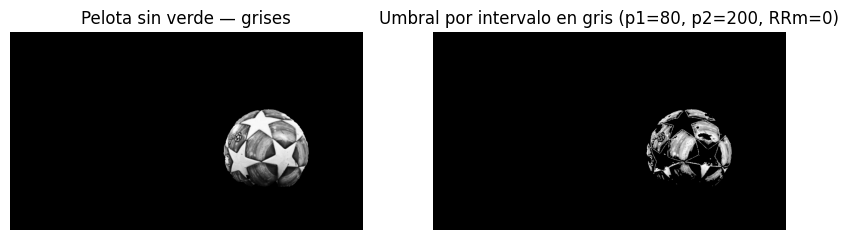

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

if "display_images" not in globals():
    def display_images(original, negative, title_original, title_negative, cmap=None):
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(original, cmap=cmap)
        plt.title(title_original)
        plt.axis("off")
        plt.subplot(1, 2, 2)
        plt.imshow(negative, cmap=cmap)
        plt.title(title_negative)
        plt.axis("off")
        plt.show()

if globals().get("pelota_bgr") is None:
    raise RuntimeError("Ejecuta primero la celda que carga pelota.jpg.")

if globals().get("image_without_green_background") is None:
    if "mascara_cesped_y_fg" not in globals():
        raise RuntimeError(
            "Ejecuta primero la celda HSV de segmentación del césped (define mascara_cesped_y_fg)."
        )
    _, _, image_without_green_background = mascara_cesped_y_fg(pelota_bgr)

gray_ball_image = cv2.cvtColor(image_without_green_background, cv2.COLOR_RGB2GRAY)

p1 = 80
p2 = 200
RRm = 0
interval_threshold_gray_image = np.zeros_like(gray_ball_image, dtype=np.uint8)
mask_interval = (gray_ball_image > p1) & (gray_ball_image < p2)
interval_threshold_gray_image[mask_interval] = gray_ball_image[mask_interval]
interval_threshold_gray_image[~mask_interval] = RRm

display_images(
    gray_ball_image,
    interval_threshold_gray_image,
    "Pelota sin verde — grises",
    f"Umbral por intervalo en gris (p1={p1}, p2={p2}, RRm={RRm})",
    cmap="gray",
)


**OPERADOR DE EXTENSIÓN**

Crea la imagen de salida con la escala de grises completa correspondiente al
intervalo de entrada definido por p1 y p2 y suprime todos los valores fuera
de ese rango

Sea i una imagen digital en escala de grises, entonces

    i1= 0 para todo p<=p1 o p>=p2,

    i1= (p-p1)*[VRRMax/(p2-p1)] para todo p1<p<p2

### Implementación — Operador de extensión (reescalado del intervalo [p1, p2])

Fuera del intervalo abierto `(p1, p2)` la salida es **0**. Dentro, cada intensidad `p` se mapea linealmente a `[0, VRRMax]` según \(i_1 = (p - p_1)\cdot\frac{VRRMax}{p_2 - p_1}\).

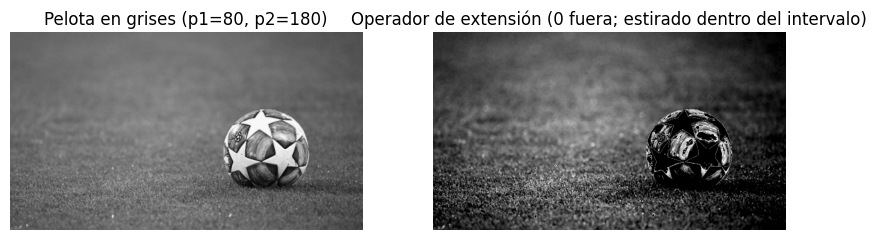

In [19]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

if "display_images" not in globals():
    def display_images(original, negative, title_original, title_negative, cmap=None):
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(original, cmap=cmap)
        plt.title(title_original)
        plt.axis("off")
        plt.subplot(1, 2, 2)
        plt.imshow(negative, cmap=cmap)
        plt.title(title_negative)
        plt.axis("off")
        plt.show()


if globals().get("grayscale_image") is None:
    raise RuntimeError("Ejecuta primero la celda que carga pelota.jpg.")

p1, p2 = 80, 180
VRRMax = 255
if p2 <= p1:
    raise ValueError("Se requiere p2 > p1.")

g = grayscale_image.astype(np.float32)
extended = np.zeros_like(g)
m = (g > p1) & (g < p2)
extended[m] = (g[m] - p1) * (VRRMax / (p2 - p1))
extended_image = np.clip(np.round(extended), 0, 255).astype(np.uint8)

display_images(
    grayscale_image,
    extended_image,
    f"Pelota en grises (p1={p1}, p2={p2})",
    "Operador de extensión (0 fuera; estirado dentro del intervalo)",
    cmap="gray",
)


**OPERADOR DE REDUCCIÓN DE NIVELES DE GRIS**

Crea la imagen de salida con un número menor de niveles de gris respecto de
la imagen de entrada. Esta se reduce a n+1 nivel de grises con la siguiente
transformación

Sea i una imagen digital en escala de grises, entonces

    i1= 0 para todo p<=p1

    q1 para todo p1<=p<=p2

    … ………………….

    qn para todo pn-1<p<RRm

### Implementación — Reducción de niveles de gris (función escalón)

Se definen umbrales crecientes `p1 < p2 < … < pn` y `n+1` niveles de salida `[q0, q1, …, qn]`: todo `p ≤ p1` → `q0`; cada tramo `(pk, pk+1]` → `qk+1`; y `p > pn` → `qn` (ajusta los intervalos si tu definición teórica usa inclusión distinta).

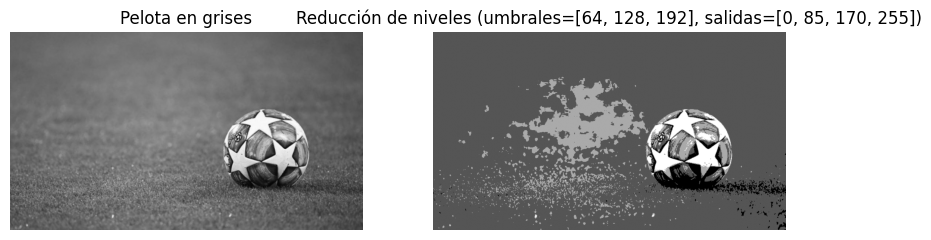

In [20]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

if "display_images" not in globals():
    def display_images(original, negative, title_original, title_negative, cmap=None):
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(original, cmap=cmap)
        plt.title(title_original)
        plt.axis("off")
        plt.subplot(1, 2, 2)
        plt.imshow(negative, cmap=cmap)
        plt.title(title_negative)
        plt.axis("off")
        plt.show()


if globals().get("grayscale_image") is None:
    raise RuntimeError("Ejecuta primero la celda que carga pelota.jpg.")


def reducir_niveles_gris(imagen: np.ndarray, umbrales: list, niveles: list) -> np.ndarray:
    """umbrales: [p1,...,pn] estrictamente crecientes. niveles: [q0,...,qn] con len=n+1."""
    g = np.asarray(imagen)
    p = np.asarray(umbrales, dtype=np.float32)
    q = np.asarray(niveles, dtype=np.uint8)
    if p.ndim != 1 or p.size < 1:
        raise ValueError("umbrales debe ser una lista no vacía p1 < p2 < ...")
    if not np.all(p[:-1] < p[1:]):
        raise ValueError("umbrales deben ser estrictamente crecientes")
    if q.size != p.size + 1:
        raise ValueError("niveles debe tener len(umbrales)+1 elementos")
    out = np.empty_like(g, dtype=np.uint8)
    out[g <= p[0]] = q[0]
    for k in range(len(p) - 1):
        out[(g > p[k]) & (g <= p[k + 1])] = q[k + 1]
    out[g > p[-1]] = q[-1]
    return out


umbrales = [64, 128, 192]
niveles = [0, 85, 170, 255]
reduced = reducir_niveles_gris(grayscale_image, umbrales, niveles)

display_images(
    grayscale_image,
    reduced,
    "Pelota en grises",
    f"Reducción de niveles (umbrales={umbrales}, salidas={list(niveles)})",
    cmap="gray",
)


**OPERADOR ADICIÓN**

Crea la imagen de salida del mismo tamaño digital de las imágenes de
entrada.


### Implementación — Operador adición

Suma píxel a píxel de dos imágenes del **mismo tamaño**. Se usa `cv2.add` para saturar en 255 (evitar desbordamiento). En Colab puedes definir `img_a` e `img_b` en grises o se generan dos ejemplos.

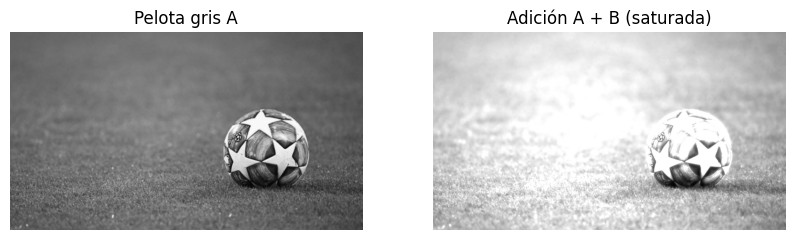

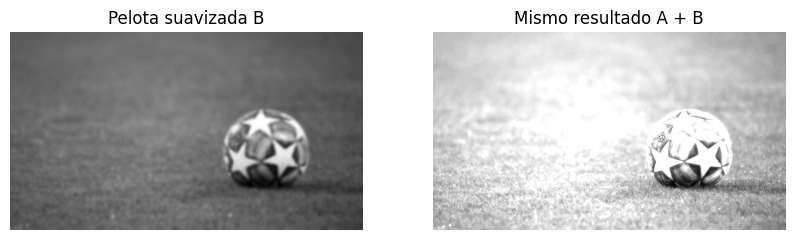

In [17]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

if "display_images" not in globals():
    def display_images(original, negative, title_original, title_negative, cmap=None):
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(original, cmap=cmap)
        plt.title(title_original)
        plt.axis("off")
        plt.subplot(1, 2, 2)
        plt.imshow(negative, cmap=cmap)
        plt.title(title_negative)
        plt.axis("off")
        plt.show()

if globals().get("grayscale_image") is None:
    raise RuntimeError("Ejecuta primero la celda que carga pelota.jpg.")

img_a = grayscale_image.copy()
img_b = cv2.GaussianBlur(grayscale_image, (21, 21), 0)
suma = cv2.add(img_a, img_b)

display_images(img_a, suma, "Pelota gris A", "Adición A + B (saturada)", cmap="gray")
display_images(img_b, suma, "Pelota suavizada B", "Mismo resultado A + B", cmap="gray")


**OPERADOR SUSTRACCIÓN**

La sustracción es una técnica útil para detectar el cambio producido en dos
imágenes que han sido captadas en dos instantes diferentes de tiempo

### Implementación — Operador sustracción

Para resaltar **cambios** entre dos instantes suele usarse la diferencia. `cv2.subtract(A,B)` recorta en 0; `cv2.absdiff(A,B)` da la magnitud del cambio sin signo.

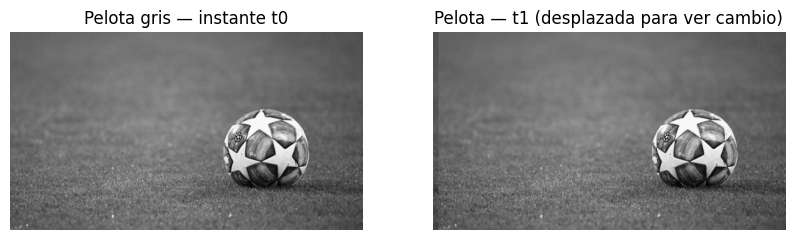

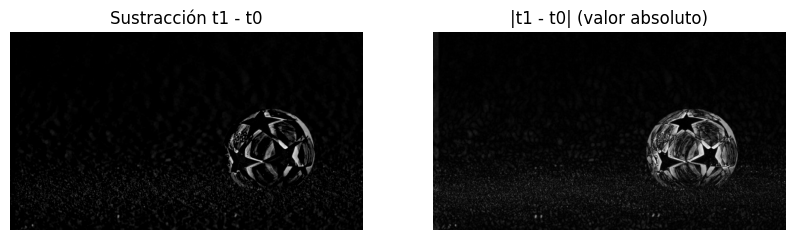

In [21]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

if "display_images" not in globals():
    def display_images(original, negative, title_original, title_negative, cmap=None):
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(original, cmap=cmap)
        plt.title(title_original)
        plt.axis("off")
        plt.subplot(1, 2, 2)
        plt.imshow(negative, cmap=cmap)
        plt.title(title_negative)
        plt.axis("off")
        plt.show()

if globals().get("grayscale_image") is None:
    raise RuntimeError("Ejecuta primero la celda que carga pelota.jpg.")

img_t0 = grayscale_image.copy()
img_t1 = np.roll(img_t0, 15, axis=1)
resta = cv2.subtract(img_t1, img_t0)
diff = cv2.absdiff(img_t1, img_t0)

display_images(img_t0, img_t1, "Pelota gris — instante t0", "Pelota — t1 (desplazada para ver cambio)", cmap="gray")
display_images(resta, diff, "Sustracción t1 - t0", "|t1 - t0| (valor absoluto)", cmap="gray")


**OPERADOR RODAJA DE PLANO DE BITS**

Diferentes bits aportan diferentes detalles a la imagen. Si suponemos que
cada pixel está representado por bits cada uno de ellos estará representado
por 8 planos, cada uno con un bit significativo y el resto 0. Tendremos desde
el plano 0 con el bit menos significativo al final hasta el plano 7 con los bits de mayor orden en todos los casos.
Sea i1 una imagen, entonces se separa el contenido de la imagen entre los
rangos 2n …2n+1 para n=0,1…7

### Implementación — Rodaja / planos de bits

Cada píxel en 8 bits: el **plano n** (n=0…7) es una imagen binaria donde cada píxel vale 255 si el bit n vale 1 y 0 si vale 0 (LSB n=0, MSB n=7).

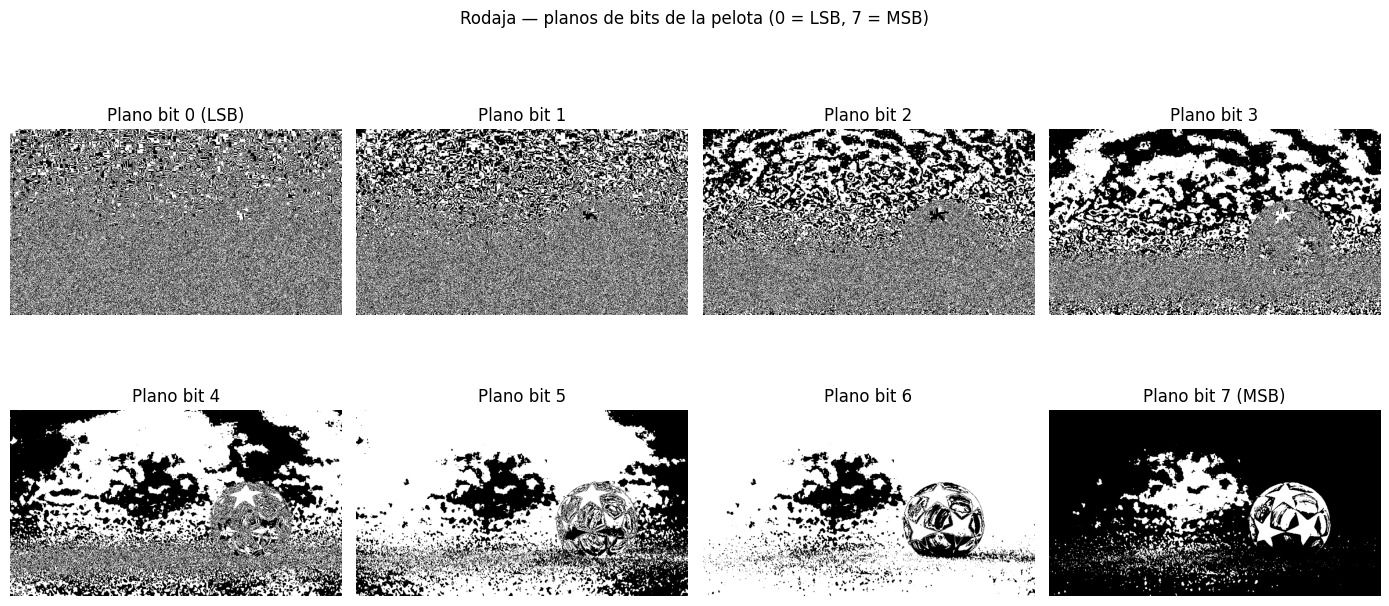

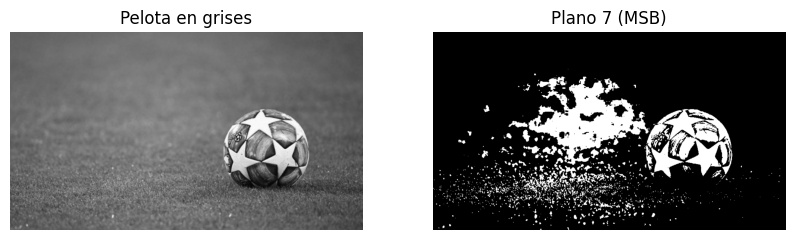

In [19]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

if "display_images" not in globals():
    def display_images(original, negative, title_original, title_negative, cmap=None):
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(original, cmap=cmap)
        plt.title(title_original)
        plt.axis("off")
        plt.subplot(1, 2, 2)
        plt.imshow(negative, cmap=cmap)
        plt.title(title_negative)
        plt.axis("off")
        plt.show()


def plano_de_bits(gray: np.ndarray, n: int) -> np.ndarray:
    if n < 0 or n > 7:
        raise ValueError("n debe estar entre 0 y 7")
    return (((gray.astype(np.uint8) >> n) & 1) * 255).astype(np.uint8)


if globals().get("grayscale_image") is None:
    raise RuntimeError("Ejecuta primero la celda que carga pelota.jpg.")

g = grayscale_image

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for n in range(8):
    ax = axes[n // 4, n % 4]
    ax.imshow(plano_de_bits(g, n), cmap="gray")
    ax.set_title(f"Plano bit {n}" + (" (LSB)" if n == 0 else " (MSB)" if n == 7 else ""))
    ax.axis("off")
plt.suptitle("Rodaja — planos de bits de la pelota (0 = LSB, 7 = MSB)")
plt.tight_layout()
plt.show()

display_images(g, plano_de_bits(g, 7), "Pelota en grises", "Plano 7 (MSB)", cmap="gray")
